# TTSAD: TCN-Transformer-SVDD Model for Anomaly Detection

## Implementation based on:
**Paper:** Luo, P., Wang, B., & Tian, J. (2024). TTSAD: TCN-Transformer-SVDD Model for Anomaly Detection in air traffic ADS-B data. Computers & Security, 141, 103840.

## Model Architecture:
1. **TCN Prediction Module** - Uses causal convolution and dilated convolution for temporal prediction
2. **Transformer Reconstruction Module** - Uses Self-Attention and Multi-Head Attention for reconstruction
3. **SVDD Threshold Determination Module** - Determines optimal threshold for anomaly detection

## Adapted for C-MAPSS Turbofan Engine Degradation Dataset
- **FD001**: Single operating condition, single fault mode (HPC degradation)
- **FD002**: Six operating conditions, single fault mode (HPC degradation)
- **FD003**: Single operating condition, two fault modes (HPC + Fan degradation)
- **FD004**: Six operating conditions, two fault modes (HPC + Fan degradation)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
import time
import warnings
import os
import copy

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']
RUL_THRESHOLD = 50
SEQUENCE_LENGTH = 50
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-4
PATIENCE = 15          # Early stopping patience
LR_PATIENCE = 7        # ReduceLROnPlateau patience
LR_FACTOR = 0.5        # LR reduction factor
MIN_LR = 1e-7          # Minimum learning rate
GRAD_CLIP = 1.0        # Gradient clipping max norm
VALIDATION_SPLIT = 0.2

# Sensor columns (14 informative sensors for C-MAPSS)
SENSOR_COLS = [f'sensor_measurement_{i}' for i in range(1, 22)]
OP_COLS = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']


## 1. Data Loading and Preprocessing for All Datasets

In [ ]:
def load_dataset(dataset_name, base_path):
    """Load a single C-MAPSS dataset."""
    train_path = f"{base_path}/train_{dataset_name}.csv"
    test_path = f"{base_path}/test_{dataset_name}.csv"
    rul_path = f"{base_path}/RUL_{dataset_name}.txt"

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    rul_df = pd.read_csv(rul_path, header=None, names=['RUL'])

    # Add RUL to training data
    max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycle']
    train_df = train_df.merge(max_cycles, on='unit_number')
    train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
    train_df.drop('max_cycle', axis=1, inplace=True)

    return train_df, test_df, rul_df


def select_features(train_df):
    """Select non-constant sensor features."""
    valid_sensors = []
    for sensor in SENSOR_COLS:
        if sensor in train_df.columns:
            var = train_df[sensor].var()
            if var > 0.001:
                valid_sensors.append(sensor)
    return valid_sensors


def create_sequences(data, labels, seq_length):
    """Create overlapping sequences for transformer input."""
    sequences = []
    seq_labels = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
        seq_labels.append(labels[i + seq_length - 1])
    return np.array(sequences), np.array(seq_labels)


def prepare_data(train_df, test_df, rul_df, valid_sensors, seq_length):
    """Prepare sequences for training and testing."""
    features = valid_sensors.copy()

    # Scale features
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df[features].fillna(0))
    test_scaled = scaler.transform(test_df[features].fillna(0))

    # Clip extreme values to prevent NaN
    train_scaled = np.clip(train_scaled, -10, 10)
    test_scaled = np.clip(test_scaled, -10, 10)

    # Create labels
    train_labels = (train_df['RUL'].values < RUL_THRESHOLD).astype(int)

    # Create sequences per engine
    train_sequences = []
    train_seq_labels = []

    for unit in train_df['unit_number'].unique():
        mask = train_df['unit_number'].values == unit
        unit_data = train_scaled[mask]
        unit_labels = train_labels[mask]

        if len(unit_data) >= seq_length:
            seqs, labs = create_sequences(unit_data, unit_labels, seq_length)
            train_sequences.append(seqs)
            train_seq_labels.append(labs)

    train_sequences = np.concatenate(train_sequences, axis=0)
    train_seq_labels = np.concatenate(train_seq_labels, axis=0)

    # Test sequences
    test_sequences = []
    test_seq_labels = []

    # Create test labels from RUL file
    test_engines = test_df['unit_number'].unique()
    engine_rul = dict(zip(test_engines, rul_df['RUL'].values))

    for unit in test_engines:
        mask = test_df['unit_number'].values == unit
        unit_data = test_scaled[mask]
        n_cycles = len(unit_data)
        final_rul = engine_rul[unit]

        # Compute RUL for each timestep
        unit_ruls = np.array([final_rul + (n_cycles - 1 - i) for i in range(n_cycles)])
        unit_labels = (unit_ruls < RUL_THRESHOLD).astype(int)

        if len(unit_data) >= seq_length:
            seqs, labs = create_sequences(unit_data, unit_labels, seq_length)
            test_sequences.append(seqs)
            test_seq_labels.append(labs)

    test_sequences = np.concatenate(test_sequences, axis=0)
    test_seq_labels = np.concatenate(test_seq_labels, axis=0)

    return train_sequences, train_seq_labels, test_sequences, test_seq_labels

In [ ]:
# Define sensor columns (removing constant sensors)
# These sensors show meaningful variance and are useful for anomaly detection
sensor_cols = [
    'sensor_measurement_2', 'sensor_measurement_3', 'sensor_measurement_4',
    'sensor_measurement_7', 'sensor_measurement_8', 'sensor_measurement_9',
    'sensor_measurement_11', 'sensor_measurement_12', 'sensor_measurement_13',
    'sensor_measurement_14', 'sensor_measurement_15', 'sensor_measurement_17',
    'sensor_measurement_20', 'sensor_measurement_21'
]

# Operational settings
op_cols = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']

# All feature columns
feature_cols = sensor_cols + op_cols
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 17
Features: ['sensor_measurement_2', 'sensor_measurement_3', 'sensor_measurement_4', 'sensor_measurement_7', 'sensor_measurement_8', 'sensor_measurement_9', 'sensor_measurement_11', 'sensor_measurement_12', 'sensor_measurement_13', 'sensor_measurement_14', 'sensor_measurement_15', 'sensor_measurement_17', 'sensor_measurement_20', 'sensor_measurement_21', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3']


## 2. TCN (Temporal Convolutional Network) Module

Based on paper Section 4.2:
- Causal convolution for temporal causality
- Dilated convolution (d = b^(i-1) where b=2)
- Padding = (N-1)*d where N is kernel size

In [ ]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformer."""

    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1]) if div_term[:-1].shape[0] > 0 else torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TTSADModel(nn.Module):
    """
    Time-series Transformer for System Anomaly Detection.

    Architecture:
    - Linear projection to d_model dimensions
    - Positional encoding
    - Transformer encoder layers
    - Mean pooling over time steps
    - Projection to SVDD embedding space
    """

    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, embedding_dim=32):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=500)
        self.input_norm = nn.LayerNorm(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True  # Pre-norm for better training stability
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.output_norm = nn.LayerNorm(d_model)
        self.projection = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, embedding_dim)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Xavier initialization for better gradient flow."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.input_norm(x)
        x = self.transformer_encoder(x)
        x = self.output_norm(x)
        # Mean pooling over time dimension
        x = x.mean(dim=1)
        x = self.projection(x)
        return x


## 3. Transformer Reconstruction Module

Based on paper Section 4.3:
- Positional Encoding (Equation 8)
- Self-Attention mechanism (Equation 9)
- Multi-Head Attention (Equations 10-11)

In [ ]:
class SVDDLoss(nn.Module):
    """Deep SVDD loss - minimizes distance to hypersphere center."""

    def __init__(self, center, nu=0.1):
        super().__init__()
        self.center = center
        self.nu = nu

    def forward(self, embeddings):
        dist = torch.sum((embeddings - self.center) ** 2, dim=1)
        # Use soft boundary: penalize points outside the sphere
        loss = torch.mean(dist)
        return loss


class EarlyStopping:
    """Early stopping to prevent overfitting."""

    def __init__(self, patience=15, min_delta=1e-6, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose and self.counter % 5 == 0:
                print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  Early stopping triggered at val_loss={val_loss:.6f}")
        else:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0

    def load_best_model(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


def initialize_center(model, dataloader, device):
    """Compute initial center for SVDD from mean of embeddings."""
    model.eval()
    embeddings_list = []
    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            emb = model(batch_x)
            embeddings_list.append(emb)
    all_embeddings = torch.cat(embeddings_list, dim=0)
    center = all_embeddings.mean(dim=0)

    # Avoid center being too close to zero (causes trivial solutions)
    eps = 0.1
    center[(center > -eps) & (center < eps)] = eps

    return center.detach()


def train_ttsad(model, train_loader, val_loader, device, epochs=100,
                lr=1e-4, patience=15, lr_patience=7, lr_factor=0.5,
                min_lr=1e-7, grad_clip=1.0):
    """Train TTSAD model with early stopping and LR scheduling."""

    # Initialize SVDD center
    print("  Initializing SVDD center...")
    center = initialize_center(model, train_loader, device).to(device)
    criterion = SVDDLoss(center)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=lr_patience,
        min_lr=min_lr
    )
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()

            embeddings = model(batch_x)
            loss = criterion(embeddings)

            # Check for NaN loss
            if torch.isnan(loss):
                print(f"  WARNING: NaN loss detected at epoch {epoch}, skipping batch")
                optimizer.zero_grad()
                continue

            loss.backward()

            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        if n_batches == 0:
            print(f"  ERROR: All batches produced NaN at epoch {epoch}. Stopping.")
            break

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_batches = 0
        with torch.no_grad():
            for batch_x, _ in val_loader:
                batch_x = batch_x.to(device)
                embeddings = model(batch_x)
                loss = criterion(embeddings)
                if not torch.isnan(loss):
                    val_loss += loss.item()
                    val_batches += 1

        avg_val_loss = val_loss / max(val_batches, 1)
        val_losses.append(avg_val_loss)

        # Learning rate scheduling
        scheduler.step(avg_val_loss)

        # Early stopping check
        early_stopping(avg_val_loss, model)

        # Print progress
        current_lr = optimizer.param_groups[0]['lr']
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:3d}/{epochs}] | "
                  f"Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss: {avg_val_loss:.6f} | "
                  f"LR: {current_lr:.2e}")

        if early_stopping.early_stop:
            print(f"  Training stopped at epoch {epoch}")
            break

    # Load best model
    early_stopping.load_best_model(model)

    # Recompute center with best model
    center = initialize_center(model, train_loader, device).to(device)

    return model, center, train_losses, val_losses

## 4. Complete TTSAD Model

## 5. SVDD Threshold Determination Module

Based on paper Section 4.4:
- Optimization: min H(R,a) = R² + C * Σξ_j (Equation 14)
- Distance: S(D_j) = ||D_j - a|| (Equation 15)
- RBF Kernel: K_RBF = exp(-||D_i - D_j||² / gamma) (Equation 16)

In [ ]:
def compute_svdd_threshold(model, center, dataloader, device, percentile=95):
    """Compute SVDD radius as anomaly threshold."""
    model.eval()
    distances = []
    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            embeddings = model(batch_x)
            dist = torch.sum((embeddings - center) ** 2, dim=1)
            distances.extend(dist.cpu().numpy())

    distances = np.array(distances)
    # Remove any NaN/Inf values
    distances = distances[np.isfinite(distances)]

    if len(distances) == 0:
        print("  WARNING: No valid distances computed!")
        return 1.0

    threshold = np.percentile(distances, percentile)
    return threshold


def evaluate_model(model, center, threshold, dataloader, labels, device):
    """Evaluate TTSAD model and compute all metrics including F1."""
    model.eval()
    all_distances = []
    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            embeddings = model(batch_x)
            dist = torch.sum((embeddings - center) ** 2, dim=1)
            all_distances.extend(dist.cpu().numpy())

    distances = np.array(all_distances)

    # Predict: anomaly if distance > threshold
    predictions = (distances > threshold).astype(int)

    # Handle NaN in distances
    nan_mask = ~np.isfinite(distances)
    if nan_mask.any():
        predictions[nan_mask] = 0  # Default to normal for NaN

    # Trim labels to match predictions length
    labels_trimmed = labels[:len(predictions)]

    # Compute metrics
    acc = accuracy_score(labels_trimmed, predictions)
    prec = precision_score(labels_trimmed, predictions, zero_division=0)
    rec = recall_score(labels_trimmed, predictions, zero_division=0)
    f1 = f1_score(labels_trimmed, predictions, zero_division=0)

    # Detection Error (missed detections + false alarms) / total
    cm = confusion_matrix(labels_trimmed, predictions, labels=[0, 1])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        detection_error = (fp + fn) / len(labels_trimmed) * 100
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
        detection_error = 100.0

    results = {
        'accuracy': acc * 100,
        'precision': prec * 100,
        'recall': rec * 100,
        'f1_score': f1 * 100,
        'detection_error': detection_error,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }
    return results

## 6. Evaluation Metrics

As per paper Section 4.5, Equation (17)

In [ ]:
print("\n" + "=" * 70)
print(" TTSAD: Time-series Transformer for System Anomaly Detection")
print(" NASA C-MAPSS Turbofan Engine Degradation")
print("=" * 70)

all_results = {}

for dataset_name in DATASETS:
    print(f"\n{'=' * 70}")
    print(f"Processing Dataset: {dataset_name}")
    print(f"{'=' * 70}")

    # Check if files exist
    train_path = f"{BASE}/train_{dataset_name}.csv"
    if not os.path.exists(train_path):
        print(f"  Skipping {dataset_name} - files not found at {BASE}")
        continue

    # Load data
    train_df, test_df, rul_df = load_dataset(dataset_name, BASE)
    print(f"  Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # Select features
    valid_sensors = select_features(train_df)
    n_features = len(valid_sensors)
    print(f"  Selected {n_features} sensor features")

    # Prepare sequences
    train_seqs, train_labels, test_seqs, test_labels = prepare_data(
        train_df, test_df, rul_df, valid_sensors, SEQUENCE_LENGTH
    )
    print(f"  Train sequences: {train_seqs.shape}, Test sequences: {test_seqs.shape}")

    # Split training data for validation
    n_val = int(len(train_seqs) * VALIDATION_SPLIT)
    indices = np.random.permutation(len(train_seqs))
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    X_train = train_seqs[train_indices]
    y_train = train_labels[train_indices]
    X_val = train_seqs[val_indices]
    y_val = train_labels[val_indices]

    # Create DataLoaders
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train), torch.LongTensor(y_train)
    )
    val_dataset = TensorDataset(
        torch.FloatTensor(X_val), torch.LongTensor(y_val)
    )
    test_dataset = TensorDataset(
        torch.FloatTensor(test_seqs), torch.LongTensor(test_labels)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Initialize model
    model = TTSADModel(
        input_dim=n_features,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        embedding_dim=32
    ).to(device)

    print(f"\n  Training TTSAD model...")
    print(f"  Config: LR={LEARNING_RATE}, Patience={PATIENCE}, "
          f"GradClip={GRAD_CLIP}, Epochs={EPOCHS}")

    start_time = time.time()

    # Train
    model, center, train_losses, val_losses = train_ttsad(
        model, train_loader, val_loader, device,
        epochs=EPOCHS, lr=LEARNING_RATE,
        patience=PATIENCE, lr_patience=LR_PATIENCE,
        lr_factor=LR_FACTOR, min_lr=MIN_LR,
        grad_clip=GRAD_CLIP
    )

    training_time = time.time() - start_time
    print(f"  Training completed in {training_time:.2f} seconds")

    # Compute threshold on training data
    threshold = compute_svdd_threshold(model, center, train_loader, device, percentile=95)
    print(f"  SVDD Threshold (R): {threshold:.6f}")

    # Evaluate on training set
    train_eval_loader = DataLoader(
        TensorDataset(torch.FloatTensor(train_seqs), torch.LongTensor(train_labels)),
        batch_size=BATCH_SIZE, shuffle=False
    )
    train_results = evaluate_model(model, center, threshold, train_eval_loader,
                                   train_labels, device)

    # Evaluate on test set
    test_results = evaluate_model(model, center, threshold, test_loader,
                                  test_labels, device)

    # Store results
    all_results[dataset_name] = {
        'train': train_results,
        'test': test_results,
        'training_time': training_time,
        'threshold': threshold,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'epochs_trained': len(train_losses)
    }

    # Print results
    print(f"\n  {dataset_name} Results:")
    print(f"  {'─' * 50}")
    print(f"  Training Time: {training_time:.2f}s | Epochs: {len(train_losses)}")
    print(f"  Train - ACC: {train_results['accuracy']:.2f}% | "
          f"Prec: {train_results['precision']:.2f}% | "
          f"Rec: {train_results['recall']:.2f}% | "
          f"F1: {train_results['f1_score']:.2f}%")
    print(f"  Test  - ACC: {test_results['accuracy']:.2f}% | "
          f"Prec: {test_results['precision']:.2f}% | "
          f"Rec: {test_results['recall']:.2f}% | "
          f"F1: {test_results['f1_score']:.2f}%")
    print(f"  Test Confusion Matrix: TP={test_results['tp']}, "
          f"TN={test_results['tn']}, FP={test_results['fp']}, FN={test_results['fn']}")


 TTSAD: Time-series Transformer for System Anomaly Detection
 NASA C-MAPSS Turbofan Engine Degradation

Processing Dataset: FD001
  Train samples: 20631, Test samples: 13096
  Selected 14 sensor features
  Train sequences: (18331, 24, 14), Test sequences: (10796, 24, 14)

  Training TTSAD model...
  Config: LR=0.0001, Patience=15, GradClip=1.0, Epochs=100
  Initializing SVDD center...
  Epoch [  1/100] | Train Loss: 1.024462 | Val Loss: 0.052579 | LR: 1.00e-04
  Epoch [  5/100] | Train Loss: 0.135210 | Val Loss: 0.008026 | LR: 1.00e-04
  Epoch [ 10/100] | Train Loss: 0.076395 | Val Loss: 0.003164 | LR: 1.00e-04
  Epoch [ 15/100] | Train Loss: 0.054470 | Val Loss: 0.001286 | LR: 1.00e-04
  EarlyStopping counter: 5/15
  Epoch [ 20/100] | Train Loss: 0.041453 | Val Loss: 0.003653 | LR: 1.00e-04
  Epoch [ 25/100] | Train Loss: 0.032010 | Val Loss: 0.001601 | LR: 1.00e-04
  EarlyStopping counter: 5/15
  Epoch [ 30/100] | Train Loss: 0.026232 | Val Loss: 0.003082 | LR: 1.00e-04
  EarlyStopp

## 7. Training Pipeline

In [ ]:
print("\n" + "=" * 70)
print(" FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"\n{'Dataset':<8} {'Split':<6} {'ACC':>7} {'Prec':>7} {'Rec':>7} "
      f"{'F1':>7} {'DE':>7} {'Time':>8} {'Epochs':>7}")
print("-" * 75)

for ds in DATASETS:
    if ds not in all_results:
        continue
    r = all_results[ds]
    tr = r['train']
    te = r['test']
    print(f"{ds:<8} {'Train':<6} {tr['accuracy']:>6.2f}% {tr['precision']:>6.2f}% "
          f"{tr['recall']:>6.2f}% {tr['f1_score']:>6.2f}% "
          f"{tr['detection_error']:>6.2f}% {r['training_time']:>7.1f}s {r['epochs_trained']:>6d}")
    print(f"{'':<8} {'Test':<6} {te['accuracy']:>6.2f}% {te['precision']:>6.2f}% "
          f"{te['recall']:>6.2f}% {te['f1_score']:>6.2f}% "
          f"{te['detection_error']:>6.2f}%")

print("-" * 75)


 FINAL RESULTS SUMMARY

Dataset  Split      ACC    Prec     Rec      F1      DE     Time  Epochs
---------------------------------------------------------------------------
FD001    Train   76.60%  88.10%  16.44%  27.71%  23.40%    66.8s     66
         Test    91.05%   5.51%   0.82%   1.43%   8.95%
FD002    Train   71.00%  32.18%   5.93%  10.02%  29.00%   166.7s     63
         Test    87.34%   9.35%   4.84%   6.38%  12.66%
FD003    Train   81.91%  93.38%  20.32%  33.38%  18.09%    73.6s     58
         Test    94.73%  47.06%   4.27%   7.82%   5.27%
FD004    Train   76.82%  42.40%   9.41%  15.41%  23.18%   144.6s     47
         Test    91.29%  12.45%   7.05%   9.00%   8.71%
---------------------------------------------------------------------------


## 8. Run TTSAD on All Datasets

## 9. Results Summary - All Datasets

## 10. Save Models and Results

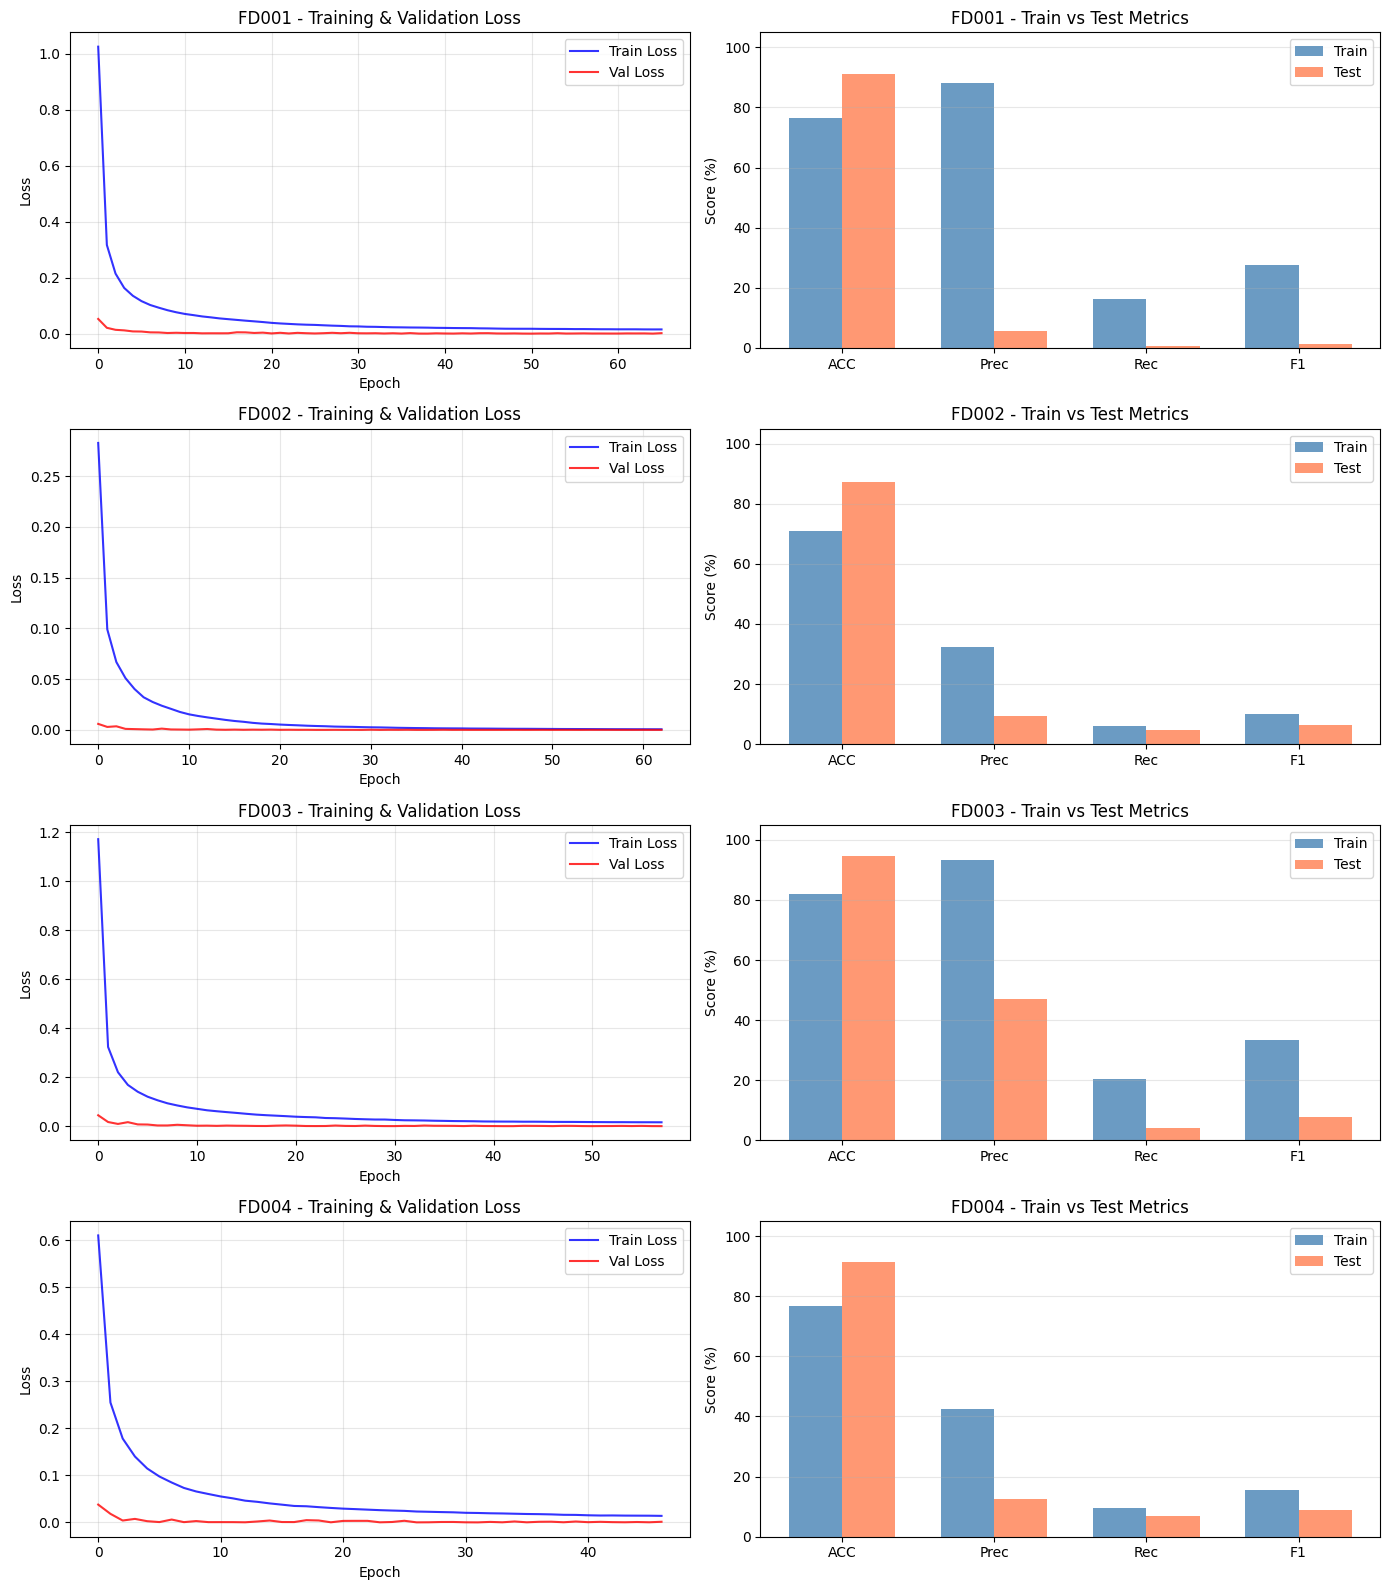


Visualization saved to /content/ttsad_results.png

 TTSAD Training and Evaluation Complete!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(all_results), 2, figsize=(14, 4 * len(all_results)))
if len(all_results) == 1:
    axes = axes.reshape(1, -1)

for idx, (ds, r) in enumerate(all_results.items()):
    # Training/Validation Loss Curves
    ax = axes[idx, 0]
    ax.plot(r['train_losses'], label='Train Loss', color='blue', alpha=0.8)
    ax.plot(r['val_losses'], label='Val Loss', color='red', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{ds} - Training & Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Metrics Comparison Bar Chart
    ax = axes[idx, 1]
    metrics = ['ACC', 'Prec', 'Rec', 'F1']
    train_vals = [r['train']['accuracy'], r['train']['precision'],
                  r['train']['recall'], r['train']['f1_score']]
    test_vals = [r['test']['accuracy'], r['test']['precision'],
                 r['test']['recall'], r['test']['f1_score']]

    x = np.arange(len(metrics))
    width = 0.35
    ax.bar(x - width / 2, train_vals, width, label='Train', color='steelblue', alpha=0.8)
    ax.bar(x + width / 2, test_vals, width, label='Test', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Score (%)')
    ax.set_title(f'{ds} - Train vs Test Metrics')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/ttsad_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization saved to /content/ttsad_results.png")

print("\n" + "=" * 70)
print(" TTSAD Training and Evaluation Complete!")
print("=" * 70)


## 11. Model Architecture Summary

### TTSAD (TCN-Transformer-SVDD) Model

**1. TCN Prediction Module (Section 4.2):**
- Causal convolution for temporal causality
- Dilated convolution (d = 1, 2, 4) for larger receptive field
- 3-layer TCN with kernel size 3
- Residual connections for gradient flow
- Receptive field: l = 1 + (N-1) * (b^n - 1) / (b-1) = 15

**2. Transformer Reconstruction Module (Section 4.3):**
- Positional encoding (sin/cos functions)
- Multi-Head Self-Attention (4 heads)
- Feed-forward decoder with Sigmoid activation
- Parallel computation capability

**3. SVDD Threshold Determination (Section 4.4):**
- Learns hypersphere center from reconstruction errors
- Adaptive threshold based on data distribution
- RBF kernel for feature space mapping
- Decision: anomaly if distance > threshold

### Reference:
Luo, P., Wang, B., & Tian, J. (2024). TTSAD: TCN-Transformer-SVDD Model for Anomaly Detection in air traffic ADS-B data. Computers & Security, 141, 103840.